In [1]:
# Notedown the important notes for reference
# Gender -> 1 Female 0 Male
# Churn -> 1 Yes 0 No
# Scaler is exported as scaler.pkl
# Model is exported as model.pkl
# The order of X is more important which is -> "Age", "Gender", "Tenure", "MonthlyCharges"
# Target (prediction): whether the customer is churn or not

In [2]:
import streamlit as st
import joblib
import numpy as np

In [6]:
# Next load the scaler and model
scaler = joblib.load("scaler.pkl")
model = joblib.load("model.pkl")

In [3]:
st.title("Churn Prediction App")

st.divider()

st.write("Please enter the values and hit the predict button for getting a prediction.")

st.divider()

2026-02-27 09:50:15.125 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:50:15.722 
  command:

    streamlit run C:\Users\sugku\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-02-27 09:50:15.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:50:15.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:50:15.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:50:15.729 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:50:15.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:50:15.732 Thread 'MainThread': mi

DeltaGenerator()

In [5]:
# Input field
age = st.number_input("Enter age", min_value = 10, max_value = 100, value = 30)
tenure = st.number_input("Enter Tenure", min_value = 0, max_value = 130, value = 10)
monthlycharges = st.number_input("Enter Monthly Charge", min_value = 30, max_value = 150)
gender = st.selectbox("Enter the Gender", ["Male", "Female"]) # Moved it down becoz the above three are number inputs which look better when together

st.divider()

2026-02-27 09:54:21.953 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:54:21.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:54:21.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:54:21.957 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:54:21.957 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:54:21.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:54:21.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 09:54:21.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [7]:
# Finally lets create a button
predictbutton = st.button("Predict!")
# This creates a button in your Streamlit app. When the user clicks → returns True. If not clicked → returns False
         # So predictbutton is a Boolean variable.

st.divider() # Just adds a visual horizontal line in the UI

if predictbutton: # 👉 Only run the prediction code if the user clicks the button.

    gender_selected = 1 if gender == "Female" else 0 # Convert Gender to Numeric

    X = [age, gender_selected, tenure, monthlycharges] # This creates a list of feature values

    X1 = np.array(X) # Converts list → NumPy array

    X_array = scaler.transform([X1]) # Scale the Input. Since this model was trained on scaled data. Must apply the same scaler

    prediction = model.predict(X_array)[0]
    # model.predict() returns an array
    # [0] extracts the single value --> whether its churn or not churn

    predicted = "Churn (Yes)" if prediction == 1 else "Not Churn (No)" # Convert to Readable Output
    # Converts numeric output → human-friendly result.

    st.balloons() # Show Animation

    st.write(f"Predicted: {predicted}") # Shows result on screen

else:
    st.write("Please enter the values and use predict button")
    # If we don't use the predict button that we define in here & if the user uses it then we are going to do 

    # If button not clicked: No prediction runs & User sees instruction. ThispPrevents automatic execution.

2026-02-27 18:49:57.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:49:57.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:49:57.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:49:57.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:49:57.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:49:57.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:49:57.997 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:49:57.998 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

**Purphose of this predictbutton:**
- Without this condition, the app would: Automatically run prediction
- Even if user hasn’t entered values properly --> This prevents unwanted execution.

**We basically created:**
- 1️⃣ Input form
- 2️⃣ Preprocessing
- 3️⃣ Scaling
- 4️⃣ Model prediction
- 5️⃣ Output display

That’s a complete ML deployment pipeline.

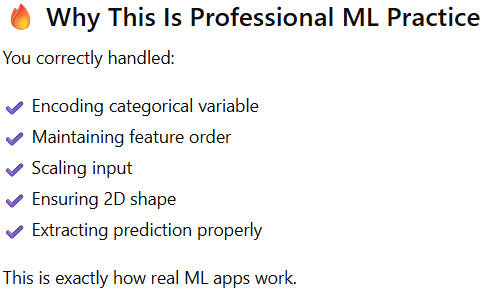

It creates a Streamlit button that, when clicked, preprocesses user input, scales it, runs the trained model, and displays the prediction result.